In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Establish standardized styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



In [3]:
# --- SIMULATING THE PRODUCTION DATA STREAM ---
np.random.seed(42)
dates = pd.date_range(start='2026-01-01', periods=100, freq='D')
depots = ['Mombasa', 'Nairobi', 'Kisumu', 'Eldoret']
data = []

for date in dates:
    for depot in depots:
        base_throughput = np.random.normal(1000, 100)
        
        # HIDDEN STRUCTURAL FAILURE: Nairobi hits a severe bottleneck after Feb 1st
        if depot == 'Nairobi' and date > pd.Timestamp('2026-02-01'):
            base_throughput *= 0.6  # 40% structural drop
            
        throughput = max(0, base_throughput + np.random.normal(0, 50))
        data.append({
            'date': date,
            'depot': depot,
            'throughput_bbl': throughput,
            'temperature_c': np.random.normal(25, 5),
            'maintenance_flag': np.random.choice([0, 1], p=[0.95, 0.05])
        })

df_eda = pd.DataFrame(data)



In [4]:
# Structural Profiling Health Check
print("=== Structural Data Profile ===")
print(df_eda.describe())
print("\n=== Missing Data Audit ===")
print(df_eda.isnull().sum())



=== Structural Data Profile ===
                      date  throughput_bbl  temperature_c  maintenance_flag
count                  400      400.000000     400.000000        400.000000
mean   2026-02-19 12:00:00      927.657137      25.543576          0.062500
min    2026-01-01 00:00:00      423.022578      11.295226          0.000000
25%    2026-01-25 18:00:00      852.886473      22.184346          0.000000
50%    2026-02-19 12:00:00      962.911783      25.559517          0.000000
75%    2026-03-16 06:00:00     1050.702460      28.889034          0.000000
max    2026-04-10 00:00:00     1451.817215      40.394404          1.000000
std                    NaN      188.189077       4.876250          0.242365

=== Missing Data Audit ===
date                0
depot               0
throughput_bbl      0
temperature_c       0
maintenance_flag    0
dtype: int64


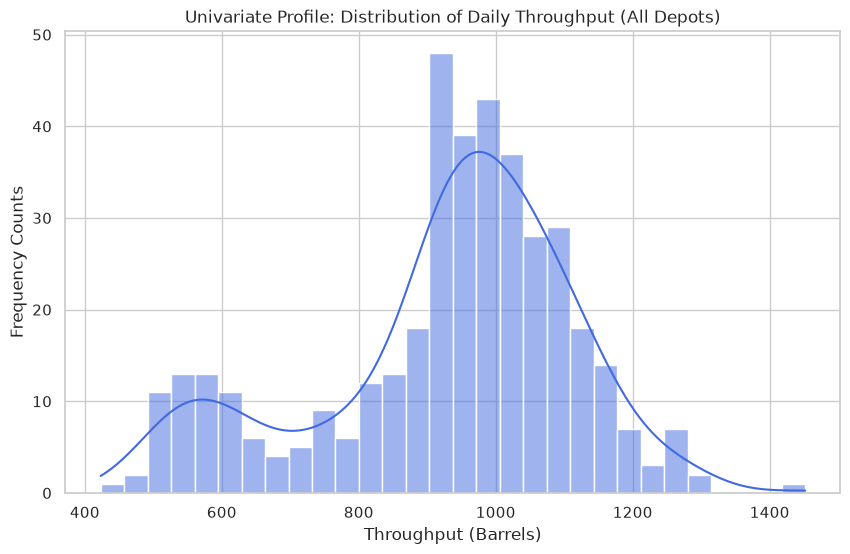

In [5]:
# Univariate Analysis: Throughput Distribution Shape
plt.figure()
sns.histplot(df_eda['throughput_bbl'], kde=True, bins=30, color='royalblue')
plt.title('Univariate Profile: Distribution of Daily Throughput (All Depots)')
plt.xlabel('Throughput (Barrels)')
plt.ylabel('Frequency Counts')
plt.show()



/tmp/ipykernel_1231200/3180420777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='depot', y='throughput_bbl', data=df_eda, palette='Set2')


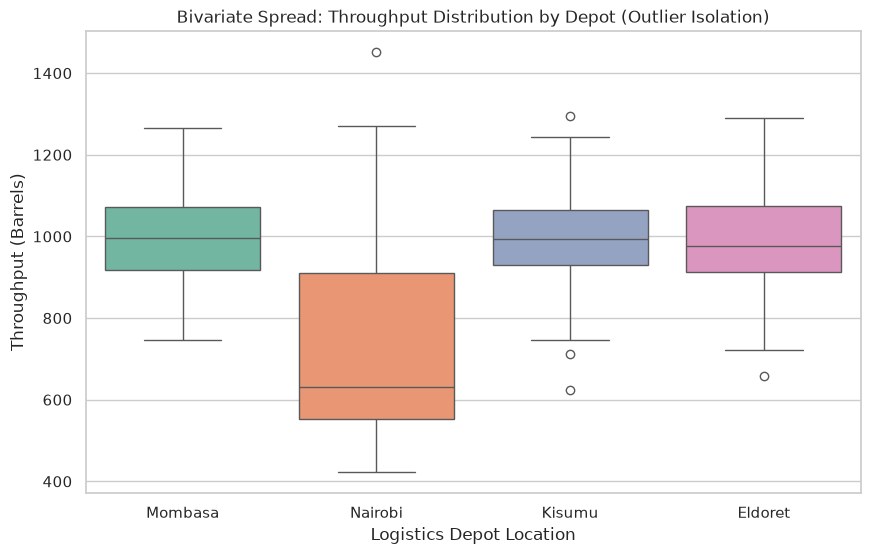

In [6]:
# Outlier and Spread Analysis via Boxplots
plt.figure()
sns.boxplot(x='depot', y='throughput_bbl', data=df_eda, palette='Set2')
plt.title('Bivariate Spread: Throughput Distribution by Depot (Outlier Isolation)')
plt.xlabel('Logistics Depot Location')
plt.ylabel('Throughput (Barrels)')
plt.show()



In [7]:
# Interactive Deep-Dive Exploration with Plotly
fig = px.box(df_eda, x='depot', y='throughput_bbl', color='depot',
             title='Interactive Diagnostic Portal: Throughput Metrics by Depot Location')
fig.show()